# Tutorial 1 — Photometry: VHS 1256 b

**What you'll learn:** How to run a photometric atmosphere retrieval with ForMoSA v2.0 —
loading multi-instrument broadband photometry, configuring the analysis with Python dataclasses,
adapting a model grid, running nested sampling, and interpreting the results.

**Target:** VHS J125601.92−125723.9 b (VHS 1256 b) — a ~140 Myr, planetary-mass companion
at ~22 pc with one of the most extreme red colours of any directly-imaged companion known.
It sits on the L/T transition and hosts a spectrum dominated by thick, silicate clouds.
It has been observed by SPHERE and NACO at the VLT, and more recently by JWST/NIRCam and JWST/MIRI.

**Data:** 14 broadband photometric points spanning 1–16 µm (SPHERE + NACO + JWST NIRCam + JWST MIRI).

**Grid:** BT-Settl (Allard et al. 2012) — Teff: 1000–3000 K, log g: 2.5–5.5

**Estimated runtime:**
- Grid adaptation: < 15 s
- Nested sampling (100 live points, nestle): ~1 min

**References:**
Miles et al. (2023, ApJL, 946, L6); Petrus et al. (2023, A&A, 670, L9)


## Section 0: Setup

Run these four cells before anything else. They check your environment, create the
working directories, download the observation data, and download the model grid.


In [1]:
# Environment check
import sys

try:
    import ForMoSA
    print(f"ForMoSA {ForMoSA.__version__} — OK")
except ImportError:
    raise ImportError(
        "ForMoSA is not installed.\n"
        "Run:  pip install ForMoSA && conda install dask netCDF4 bottleneck"
        "or: install from source:  git clone https://github.com/ForMoSA/ForMoSA.git && cd ForMoSA && pip install ."
    )

print(f"Python {sys.version.split()[0]}")


ForMoSA 2.0.0 — OK
Python 3.11.13


In [2]:
# Workspace setup
from pathlib import Path

TUTORIAL_DIR = Path(".").resolve()   # directory containing this notebook

for d in ["data", "adapted_grid", "results", "grid"]:
    (TUTORIAL_DIR / d).mkdir(exist_ok=True)

print(f"Working directory : {TUTORIAL_DIR}")
print("Subdirectories    : data/  adapted_grid/  results/  grid/")


Working directory : /Users/rajpoot/Karmabhumi/Packages/ForMoSA/docs/tutorials/photo/vhs1256b
Subdirectories    : data/  adapted_grid/  results/  grid/


In [3]:
# Data download + validation
import urllib.request
from astropy.io import fits

DATA_FILE = TUTORIAL_DIR / "data" / "VHS1256b_photometry.fits"
DATA_URL  = (
    "https://github.com/exoAtmospheres/ForMoSA/releases/download/"
    "tutorial-data-v1/VHS1256b_photometry.fits"
)

if not DATA_FILE.exists():
    print("Downloading observation data (~1 MB)...")
    urllib.request.urlretrieve(DATA_URL, DATA_FILE)
    print("Done.")
else:
    print(f"Data already present: {DATA_FILE.name}")

# Validate required data keys. Support two FITS layouts:
# 1) Multiple HDUs named WAV/FLX/ERR/...
# 2) A single BINTable HDU with columns WAV/FLX/ERR/...
REQUIRED = {"WAV", "WAVE_UNIT", "FLX", "ERR", "FAC", "INS", "FILT"}
with fits.open(DATA_FILE) as hdul:
    ext_names = {hdu.name.upper() for hdu in hdul[1:] if getattr(hdu, "name", None)}

    # Find first table HDU with columns, if any
    table_hdu = next(
        (hdu for hdu in hdul[1:] if hasattr(hdu, "columns") and hdu.columns is not None),
        None,
    )
    table_cols = ({name.upper() for name in table_hdu.columns.names} if table_hdu is not None else set())

# Prefer table-column validation when present; otherwise validate extension names
available = table_cols if table_cols else ext_names
missing = REQUIRED - available
if missing:
    mode = "table columns" if table_cols else "FITS extensions"
    raise RuntimeError(
        f"Missing required {mode}: {sorted(missing)}. "
        f"Found: {sorted(available)}"
    )

print("\nValidation source:", "BINTable columns" if table_cols else "FITS extensions")
print("Required keys (marked ✓):")
for name in sorted(available):
    mark = "✓" if name in REQUIRED else " "
    print(f"  {mark} {name}")
print("\nAll required keys present — data is valid.")


Data already present: VHS1256b_photometry.fits

Validation source: BINTable columns
Required keys (marked ✓):
  ✓ ERR
  ✓ FAC
  ✓ FILT
  ✓ FLX
  ✓ INS
    RES
  ✓ WAV
  ✓ WAVE_UNIT

All required keys present — data is valid.


In [4]:
# Grid download
# The full BT-Settl grid is ~1 GB. Once downloaded, keep it —
# it works for all ForMoSA tutorials and your own science.
import urllib.request

GRID_FILE = TUTORIAL_DIR / "grid" / "BT-Settl.nc"
GRID_URL  = "https://drive.usercontent.google.com/download?id=1wvf4A-DupdVnYIpK_HmHE-fobqnYtvEz&export=download&confirm=t"

# Override GRID_FILE here if you already have the grid elsewhere:
# GRID_FILE = Path("/path/to/your/BT-Settl.nc")

if not GRID_FILE.exists():
    print("Downloading BT-Settl model grid (~1 GB). This takes a few minutes.\n")
    try:
        from tqdm import tqdm
        class _Progress(tqdm):
            def update_to(self, b=1, bs=1, ts=None):
                if ts: self.total = ts
                self.update(b * bs - self.n)
        with _Progress(unit="B", unit_scale=True, desc="BT-Settl.nc") as t:
            urllib.request.urlretrieve(GRID_URL, GRID_FILE, reporthook=t.update_to)
    except ImportError:
        def _progress(count, bs, total):
            pct = min(100, count * bs / total * 100)
            print(f"\r  {pct:.1f}%  {count*bs/1e6:.1f}/{total/1e6:.1f} MB",
                  end="", flush=True)
        urllib.request.urlretrieve(GRID_URL, GRID_FILE, reporthook=_progress)
        print()
    print(f"\nSaved: {GRID_FILE}")
else:
    print(f"Grid already present: {GRID_FILE.name}")

import xarray as xr
grid = xr.open_dataset(GRID_FILE, decode_cf=False)
par_names = grid.attrs.get("par", [])
par_units = grid.attrs.get("unit", [])
print(f"\nGrid dimensions: {dict(grid.sizes)}")
for i, (key, name, unit) in enumerate(zip(["par1", "par2", "par3", "par4"],
                                           par_names or ["par1","par2","par3","par4"],
                                           par_units or ["","","",""])):
    if key in grid.coords:
        vals = grid[key].values
        print(f"  {name} {unit}: {vals[0]:.1f} → {vals[-1]:.1f}  ({len(vals)} points)")

# Display the grid content in a notebook
# Click on the data repo icon (on the right) to show the full content if needed
grid

Grid already present: BT-Settl.nc

Grid dimensions: {'wavelength': 1161983, 'par1': 22, 'par2': 7}
  teff (K): 1200.0 → 2900.0  (22 points)
  logg (dex): 2.5 → 5.5  (7 points)


<xarray.Dataset>
Dimensions:     (wavelength: 1161983, par1: 22, par2: 7)
Coordinates:
  * wavelength  (wavelength) float64 0.3001 0.3001 0.3001 ... 30.0 30.0 30.0
  * par1        (par1) float64 1.2e+03 1.3e+03 1.4e+03 ... 2.8e+03 2.9e+03
  * par2        (par2) float64 2.5 3.0 3.5 4.0 4.5 5.0 5.5
Data variables:
    grid        (wavelength, par1, par2) float64 ...
Attributes:
    key:      ['par1', 'par2']
    par:      ['teff', 'logg']
    title:    ['Teff', 'log(g)']
    unit:     ['(K)', '(dex)']
    res:      [ 60003.04331194  60004.04327964  60005.04321604 ... 149994.483...

## Section 1: The science

### Why photometry?

A spectrum tells you the detailed shape of an atmosphere's emission as a function of wavelength.
Photometry gives you the *integrated* flux in broad bands — less information per data point, but
easier to obtain across a wide wavelength range and across many instruments.

From photometry alone you can constrain:
- **Teff** (effective temperature) — sets the overall luminosity and colour
- **log g** (surface gravity) — affects the pressure-broadening of molecular bands and the
  cloud sedimentation efficiency
- **Radius** — via the Stefan-Boltzmann law once Teff and luminosity are known
- **Bolometric luminosity** — integrating the SED over all bands

### VHS 1256 b

VHS 1256 b was first identified by Gauza et al. (2015) as an exceptionally red, young companion
to the M dwarf binary VHS J1256−1257. Its youth (~140 Myr, Upper-Centaurus Lupus association)
means low surface gravity and active cloud formation — exactly why it sits on the L/T transition
and looks so red. JWST observations (Miles et al. 2023) confirmed silicate absorption at 8–10 µm
and CO₂ at 4.2 µm, making it one of the most well-characterised sub-stellar atmospheres to date.

We fit 14 photometric points spanning 1.5–16 µm:
- **Paranal**
    - **SPHERE**
        - IRDIS_D_H23_2
        - IRDIS_D_H23_3
        - IRDIS_D_K12_1
        - IRDIS_D_K12_2
    - **NACO**
        - Lp
        - NB405
        - Mp
          
- **JWST**
    - **NIRCam**
        - F250M
        - F300M
        - F356W
        - F410M
        - F444W
    - **MIRI**
        - F1140C
        - F1550C

### Expected results

Literature retrieval (Petrus et al. 2023): Teff ≈ 1200–1400 K, log g ≈ 3.5–4.5.
BT-Settl struggles with the very red colours of VHS 1256 b (no cloud microphysics),
so we expect the fit to be imperfect — but it's a good benchmark case.


## Section 2: Inspect the data

In [5]:
from astropy.table import Table
import matplotlib.pyplot as plt

table = Table.read(DATA_FILE, format="fits")
wav  = table["WAV"].data.astype(float)       # wavelength (µm)
flx  = table["FLX"].data.astype(float)       # flux (W/m²/µm)
err  = table["ERR"].data.astype(float)       # 1-σ uncertainty
fac  = table["FAC"].data                     # facility names
ins  = table["INS"].data                     # instrument names
filt = table["FILT"].data                    # filter names

print(f"Number of photometric points: {len(wav)}")
print(f"Wavelength range: {wav.min():.2f} – {wav.max():.2f} µm\n")
table.pprint(max_width=-1)

Number of photometric points: 14
Wavelength range: 1.59 – 15.51 µm

 WAV   WAVE_UNIT       FLX              ERR        RES   FAC    INS        FILT    
------ --------- ---------------- ---------------- --- ------- ------ -------------
1.5888        um  8.569233656e-17 3.8338054057e-18   0 Paranal SPHERE IRDIS_D_H23_2
1.6671        um 1.0129485005e-16 5.6438364192e-18   0 Paranal SPHERE IRDIS_D_H23_3
  2.11        um          7.5e-17            6e-18   0 Paranal SPHERE IRDIS_D_K12_1
 2.251        um          7.1e-17            6e-18   0 Paranal SPHERE IRDIS_D_K12_2
 2.523        um        3.345e-17        2.714e-18   0    JWST NIRCam         F250M
 3.067        um        2.441e-17        1.868e-18   0    JWST NIRCam         F300M
  3.58        um        2.549e-17        1.785e-18   0    JWST NIRCam         F356W
   3.8        um    4.0100929e-17 5.4204869971e-18   0 Paranal   NACO            Lp
  4.05        um         3.22e-17          7.8e-18   0 Paranal   NACO         NB405
 4.084  

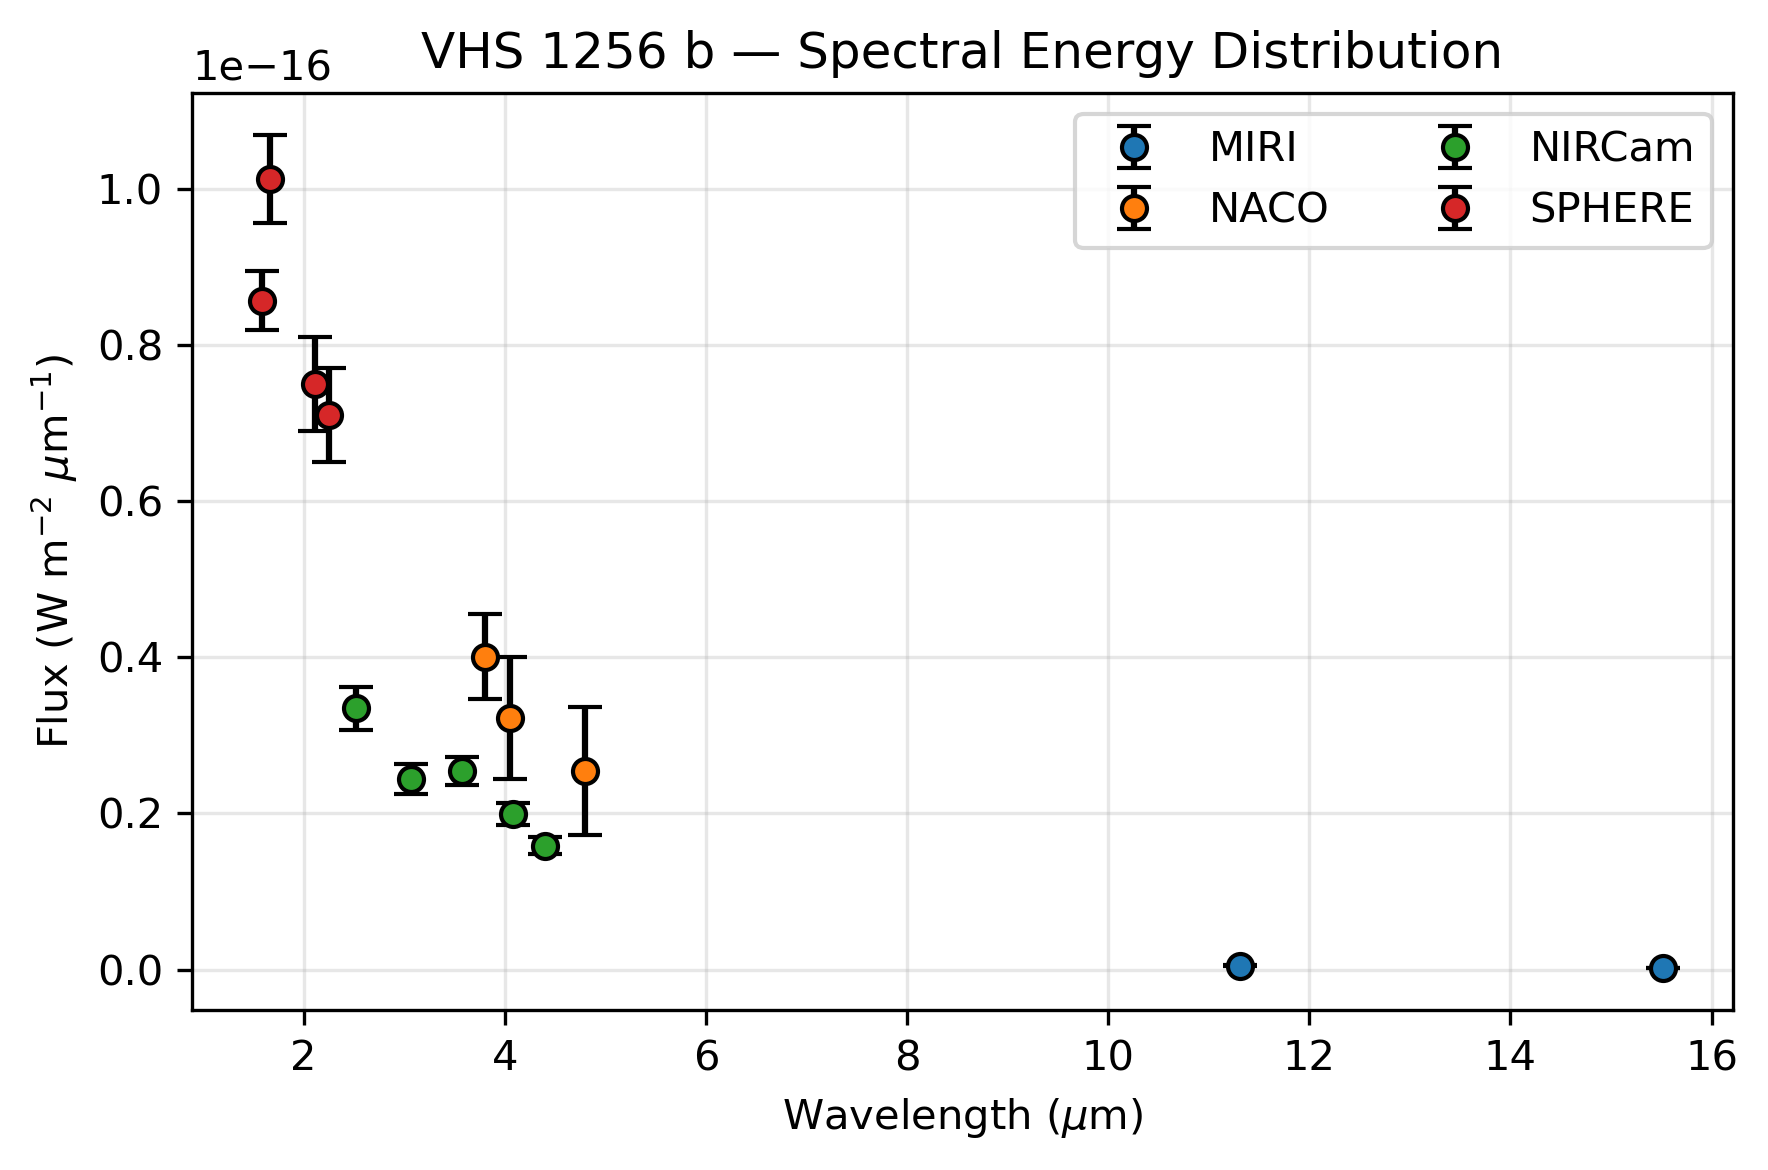

In [6]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# Plot each point with error bars, colored by instrument
grouped = table.group_by("INS")
for group in grouped.groups:
    inst_name = group["INS"][0]  # Get instrument name from first row of group
    mask = table["INS"] == inst_name
    ax.errorbar(wav[mask], flx[mask], yerr=err[mask], fmt="o", mec="k", ecolor="k", capsize=4, label=inst_name)

ax.set_xlabel(r"Wavelength ($\mu$m)")
ax.set_ylabel(r"Flux (W m$^{-2}$ $\mu$m$^{-1}$)")
ax.set_title("VHS 1256 b — Spectral Energy Distribution")
ax.grid(alpha=0.3)
ax.legend(ncols=2)
plt.tight_layout()
plt.show()

## Section 3: Configure the analysis

### Part A: Setting up the configurations

ForMoSA v2.0 uses four Python dataclasses to configure a run. Each dataclass
groups related settings — you only need to set the ones that differ from the defaults.

| Dataclass | Controls |
|-----------|----------|
| `ConfigPath` | File paths (observation, grid, output directories) |
| `ConfigAdapt` | How the grid is resampled to match the observations |
| `ConfigInversion` | Wavelength fitting window, nested sampling algorithm |
| `ConfigParameters` | Prior on each free parameter |
| `Config_NS` | Settings for Nested Sampling Algorithms |


In [7]:
from ForMoSA.config.global_config import ConfigPath, ConfigAdapt, ConfigInversion, ConfigParameters, Config_NS, ConfigNestle

# ──────────────────────────── Paths ────────────────────────────
config_path = ConfigPath(
    observation_path=[str(DATA_FILE)],          # list of FITS files
    adapt_store_path=str(TUTORIAL_DIR / "adapted_grid"),
    result_path=str(TUTORIAL_DIR / "results"),
    model_path=str(GRID_FILE),
)

# ────────────────────────── Adaptation ──────────────────────────
# Defaults are fine for photometry: no continuum removal (res_cont="NA"),
# target resolution = observation resolution (target_res_obs="obs").
config_adapt = ConfigAdapt()

# ────────────────────────── Inversion ──────────────────────────
config_inversion = ConfigInversion(
    wav_fit   = ["2.0, 16.0"],   # µm range covering all 14 filters
    ns_algo   = "nestle",        # use nestle in Jupyter (PyMultiNest needs MPI)
    npoints   = 100,             # live points (increase for production runs)
    logL_type = ["chi2"],        # standard χ² likelihood
)

# ────────────────────────── Parameters ──────────────────────────
# Syntax for priors: ["type", "min", "max"] or ["constant", "value"]
# par1 = Teff (K), par2 = log g (dex) — read from grid attributes above
config_params = ConfigParameters(
    par1  = ["uniform", "1200", "2800"],    # Teff range from BT-Settl grid
    par2  = ["uniform", "2.5", "5.5"],      # log g range 
    r     = ["uniform", "0.5", "2.0"],      # radius (R_Jup)
    d     = ["constant", "21.15"]            # distance (pc) — fixed to literature value for VHS 1256 b (21.15 ± 0.22 pc)
)

# ───────────────────── Nested Sampling Algo ───────────────────────
# Initialize the nested sampling configuration with the chosen algorithm (here, nestle)
config_ns = Config_NS(ConfigNestle())


# Display the configuration for verification
print("Configuration:")
print(f"  wav_fit : {config_inversion.wav_fit[0]} µm")
print(f"  Fixed parameters: distance = {config_params.d[1]} pc")
print(f"  Free    : {config_params.par1[1]} - {config_params.par1[2]} (Teff), {config_params.par2[1]} - {config_params.par2[2]} (log g), {config_params.r[1]} - {config_params.r[2]} (r)")

Configuration:
  wav_fit : 2.0, 16.0 µm
  Fixed parameters: distance = 21.15 pc
  Free    : 1200 - 2800 (Teff), 2.5 - 5.5 (log g), 0.5 - 2.0 (r)


### Saving the configuration for later reference

In [8]:
# Saving the configuration for later reference
from ForMoSA.config.global_config import ConfigGenerator  

# Initialize the generator
generator = ConfigGenerator()
  
# Create a dictionary of your configuration objects  
generator.config.update({
    "config_path": config_path,
    "config_adapt": config_adapt,
    "config_inversion": config_inversion,
    "config_parameters": config_params,
})
  
# Save to an .ini file  
generator.save(path=TUTORIAL_DIR, name="photo_config.ini")

INFO         Save config to path /Users/rajpoot/Karmabhumi/Packages/ForMoSA/docs/tutorials/photo/vhs1256b

### Loading of the configuration file

If you would like to use an already generated configuration file, then you have to load it first so that it can be passed to all algorithms. The Nested Sampling class will use only the parameters relevant to the algorithm you are using.

In [13]:
from ForMoSA.config.global_config import ConfigLoader, Config_NS

# Load the configuration from the .ini file we just saved
cfg = ConfigLoader(str(TUTORIAL_DIR/'photo_config.ini'))
sections = cfg.load()

config_path = sections.get("config_path")
config_adapt = sections.get("config_adapt")
config_inversion = sections.get("config_inversion")
config_params = sections.get("config_parameters")

# Initialize Config_NS with the loaded configuration sections
config_ns = Config_NS(
                nestle=cfg.config['config_nestle'],
                pymultinest=cfg.config['config_pymultinest'],
                ultranest=cfg.config['config_ultranest']
            )

INFO         Config file loaded

### Step B: Setting up the Analysis object

Analysis object is the main interface to run the ForMoSA using the provided configuration. It allows you to run the adaptation and inversion steps, or skip them if already done, and proceed directly to plotting results.

In [15]:
from ForMoSA import Analysis

# If this is the first time you are adapting your model grid, or if you need to re-adapt it, set adapted = False
# If you have already adapted your model grid, set adapted = True
adapted = False

# If you want to perform the fit, set fitted = False
# If you only want to generate plots, set fitted = True
fitted = False

analysis = Analysis(config_path, adapted=adapted, fitted=fitted, log_level='error')

INFO         Filter data for Paranal/SPHERE.IRDIS_D_H23_2 successfully found

INFO         Setting wavelength unit to um for filter Paranal/SPHERE.IRDIS_D_H23_2 to um

INFO         Filter data for Paranal/SPHERE.IRDIS_D_H23_3 successfully found

INFO         Setting wavelength unit to um for filter Paranal/SPHERE.IRDIS_D_H23_3 to um

INFO         Filter data for Paranal/SPHERE.IRDIS_D_K12_1 successfully found

...

INFO         Setting wavelength unit to um for filter Paranal/NACO.Mp to um

INFO         Filter data for JWST/MIRI.F1140C successfully found

INFO         Setting wavelength unit to um for filter JWST/MIRI.F1140C to um

INFO         Filter data for JWST/MIRI.F1550C successfully found

INFO         Setting wavelength unit to um for filter JWST/MIRI.F1550C to um

<div class="alert alert-block alert-warning"> 

<b>NOTE:</b> Here we create the main analysis class. For the purpose of not overcharging the notebook, we use log_level = 'error'
The different options are:
<ul>
    <li> 'info' (basic information),
    <li> 'debug' (basic information + additional debugging information)
    <li> 'warning' (only warning messages)
    <li> 'error' (only error messages, so typically no message unless you have an error in the code)
    <li> 'critical' (same thing as 'error' but for critical ones)
    <li> 'off' or None (no logging)
</ul>
</div>


## Section 4: Adapt the grid

The grid is pre-computed at native model resolution. Before fitting, ForMoSA
*adapts* it: it evaluates the model flux through each photometric filter,
producing a much smaller grid of synthetic photometry that is directly comparable
to your observations.

For photometry, adaptation is fast — there is no spectral convolution, just
filter integration via the SVO Filter Profile Service (downloaded automatically
the first time each filter is used).

Set `adapted=True` on subsequent runs to skip this step and load the cached grid.


In [16]:
if not adapted:
    # Adaptation convolves each model spectrum to match the SINFONI resolution
    # and resamples it onto the observed wavelength grid.
    print("Adapting grid (convolution + resampling)...")
    analysis.adapt(config_adapt, config_inversion)
    print("Done. Set adapted=True to skip on re-runs.")
else:
    print("Skipping adaptation. Set adapted=False to re-run.")

Adapting grid (convolution + resampling)...


INFO         Filter data for Paranal/SPHERE.IRDIS_D_H23_2 successfully found

INFO         Filter data for Paranal/SPHERE.IRDIS_D_H23_3 successfully found

INFO         Filter data for Paranal/SPHERE.IRDIS_D_K12_1 successfully found

INFO         Filter data for Paranal/SPHERE.IRDIS_D_K12_2 successfully found

...

INFO         Setting wavelength unit to um for filter Paranal/NACO.Mp to um

INFO         Setting wavelength unit to um for filter JWST/MIRI.F1140C to um

INFO         Setting wavelength unit to um for filter JWST/MIRI.F1550C to um

BT-Settl_[JWST+Paranal]_[MIRI+NACO+NIRCam+SPHERE]_[14filters]_Photometric: 100%|██████████| 154/154 [00:14<00:00, 10.75model/s]


Done. Set adapted=True to skip on re-runs.


## Section 5: Run the nested sampling fit

Nested sampling explores the prior volume and computes the Bayesian evidence
(log Z) alongside the posterior distributions. We use **Nestle** here because
it runs in a single process — ideal for a notebook environment.

For production runs with more live points or more free parameters, switch to
`ns_algo="pymultinest"` and run with MPI (see Tutorial 6).

The `npoints=100` setting is a good starting point for a quick check.
For publication-quality posteriors, use 300–500 live points.


In [17]:
if not fitted:
    print(f"Running {config_inversion.ns_algo} with {config_inversion.npoints} live points...")
    analysis.nested_sampling(config_params, config_adapt, config_inversion, config_NS=config_ns)
    print("\nFit complete. Results saved to results/")
else:
    print("Skipping fit. Set fitted=False to run the fit.")

Running nestle with 100 live points...


INFO         Restrict subgris and observations to windows ['2.0, 16.0']

INFO           Adding Photometric Subgrid with name [JWST+Paranal]_[MIRI+NACO+NIRCam+SPHERE]_[14filters] to the set
         of subgrids

INFO           Adding Photometric Observation with name [JWST+Paranal]_[MIRI+NACO+NIRCam+SPHERE]_[14filters] to the
         set of observations

INFO         Algorithm for the Nested Sampling: nestle

...

INFO         Summary for the Nested Sampling parameters:                                                           
             name      kind     prior             value  fixed   scope obs_index                                   
         0  par1      GRID   uniform  [1200.0, 2800.0]  False  global      None                                    
         1  par2      GRID   uniform        [2.5, 5.5]  False  global      None                                    
         2     r    RADIUS   uniform        [0.5, 2.0]  False  global      None                                    
         3     d  DISTANCE  constant             21.15   True  global      None

it=  2568 logz=-964.477079625314

INFO         Time spent: 197.88223814964294

INFO         Saving results


Fit complete. Results saved to results/


## Section 6: Results

ForMoSA produces four diagnostic plots saved to `results/`:

| File | Shows |
|------|-------|
| `corner.pdf` | Posterior distributions and pairwise correlations |
| `chains.pdf` | Sample chains and weights (convergence check) |
| `radar.pdf` | Radar diagram of median ± 1σ for each parameter |
| `best_fit.pdf` | Best-fit model vs. observed data + residuals |


INFO         Plotting all the observations ['[JWST+Paranal]_[MIRI+NACO+NIRCam+SPHERE]_[14filters]']

INFO           Plotting transmission curve of filter Paranal/SPHERE.IRDIS_D_K12_1

INFO           Plotting transmission curve of filter Paranal/SPHERE.IRDIS_D_K12_2

INFO           Plotting transmission curve of filter JWST/NIRCam.F250M

INFO           Plotting transmission curve of filter JWST/NIRCam.F300M

...

INFO           Plotting transmission curve of filter JWST/NIRCam.F444W

INFO           Plotting transmission curve of filter Paranal/NACO.Mp

INFO           Plotting transmission curve of filter JWST/MIRI.F1140C

INFO           Plotting transmission curve of filter JWST/MIRI.F1550C

======== Nested Sampling Summary ====================
LogZ = -964.151 ± 0.477

Posterior estimates (median ± 1 sigma interval)

Teff        :  1200.0913 -  0.0713 +  0.1304 [1200.0200, 1200.2218]  MAP=1200.0131
log(g)      :     5.4965 -  0.0052 +  0.0024 [5.4913, 5.4989]  MAP=5.4996
r           :     0.5001 -  0.0001 +  0.0001 [0.5000, 0.5002]  MAP=0.5001


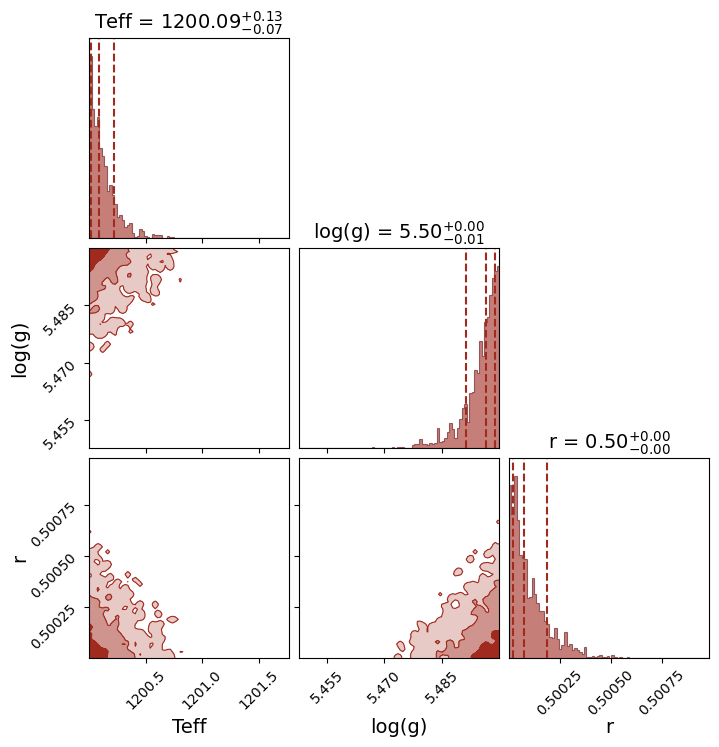

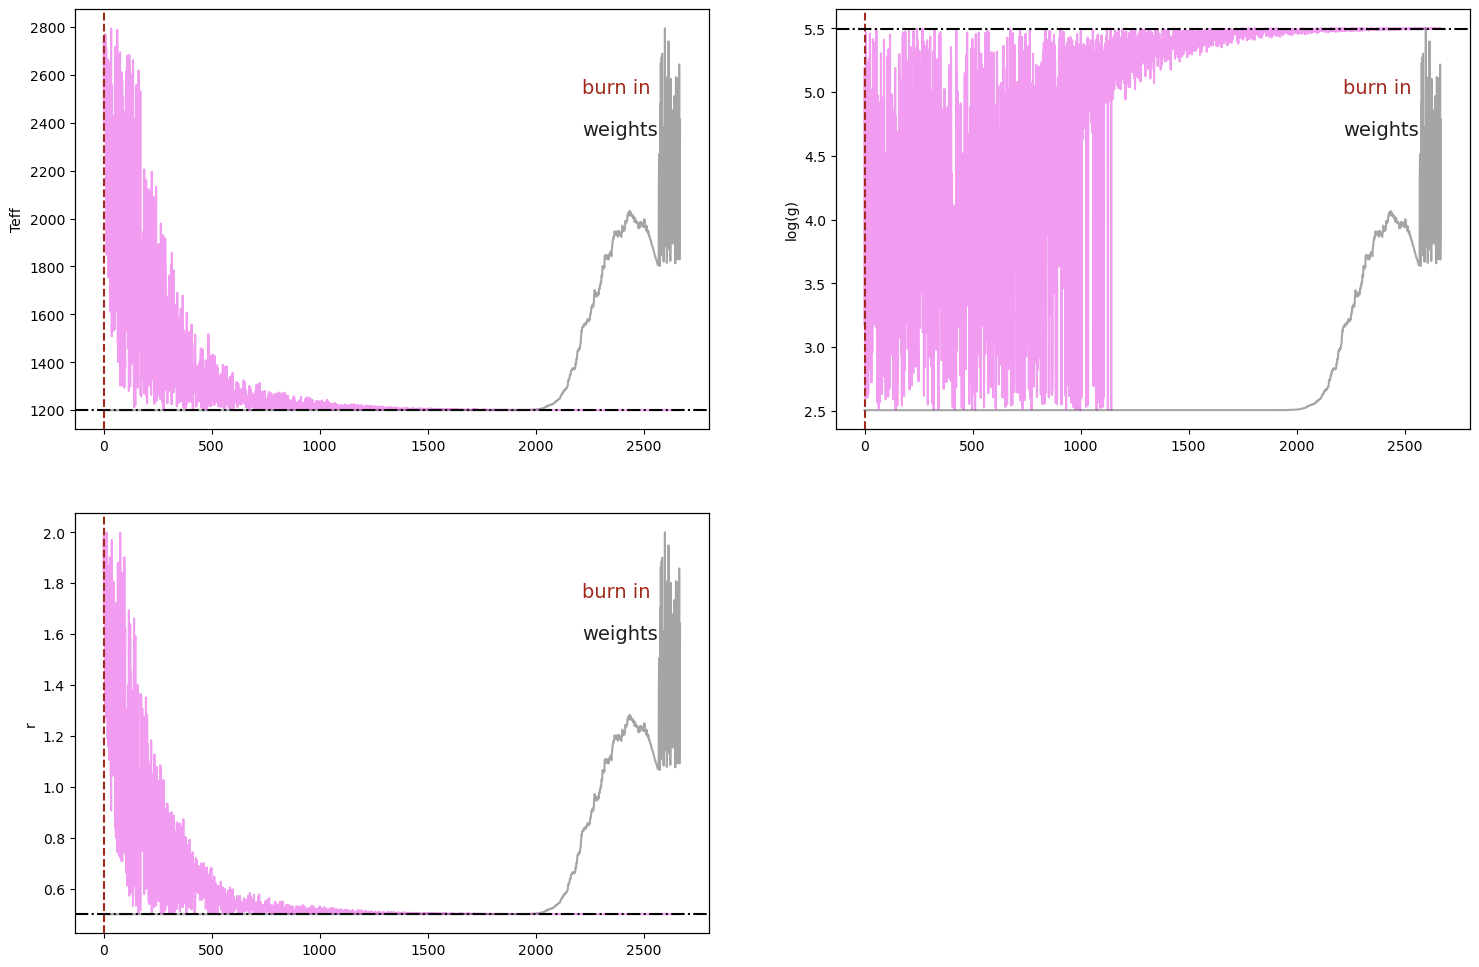

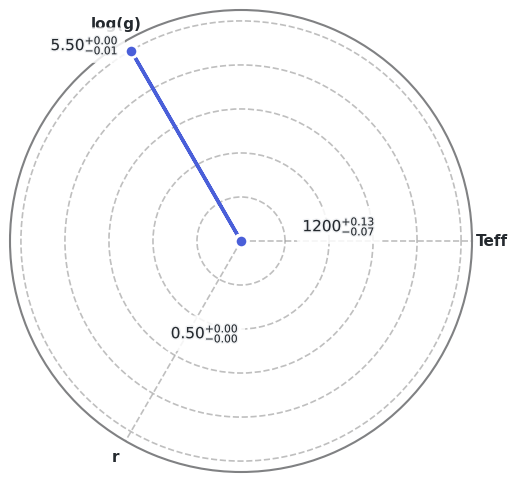

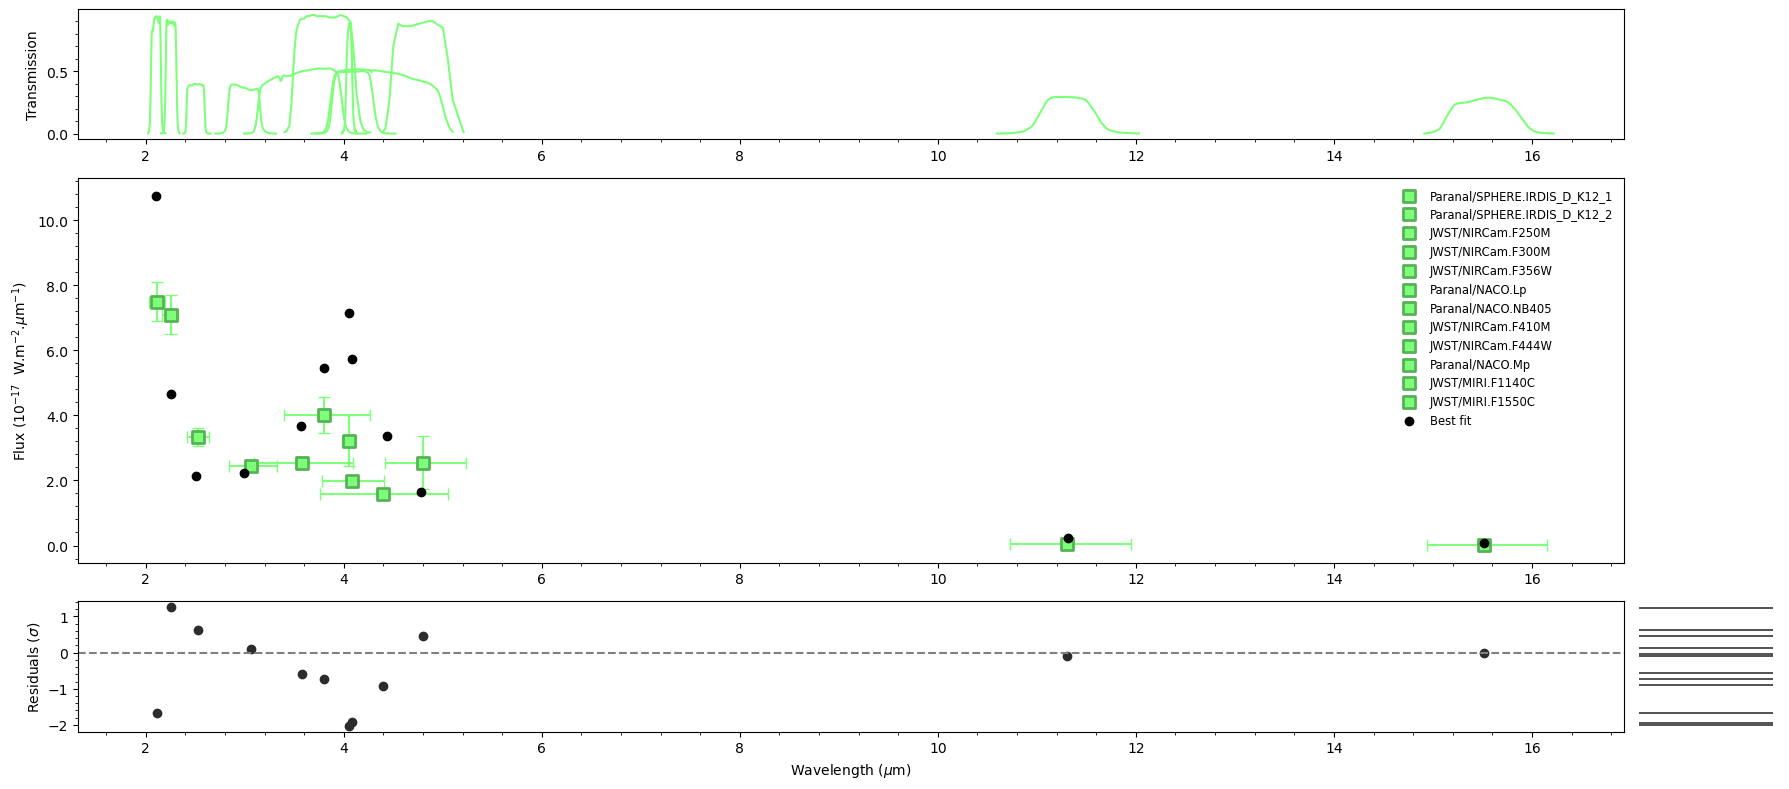

In [18]:
# Plot all results
# The figures are also saved as PDFs in results/
analysis.plot(analysis.ns.results, plot_native_model=False)

# Print a numerical summary
print(analysis.ns.results.summary(sigma=1))

## Section 7: INI file alternative

The dataclass approach above is recommended — everything lives in one place
and is easy to version-control. If you prefer an INI file (closer to ForMoSA v1.x
and convenient for cluster runs), use `ConfigGenerator` to create a default
template and `ConfigLoader` to load it.


In [ ]:
from ForMoSA.config.global_config import ConfigGenerator, ConfigLoader, Config_NS

# 1. Generate a default config.ini in TUTORIAL_DIR
generator = ConfigGenerator()
generator.save(str(TUTORIAL_DIR), "config.ini")
print(f"Default config written to: {TUTORIAL_DIR / 'config.ini'}")
print("Open it in a text editor, fill in the paths and parameters, then load it:")


In [ ]:
# 2. Load the config (after editing the .ini manually or programmatically)
# cfg = ConfigLoader(str(TUTORIAL_DIR / "config.ini"))
# sections = cfg.load()
#
# 3. Run — identical to the dataclass workflow:
# analysis = Analysis(cfg.config["config_path"], adapted=False, fitted=False)
# analysis.adapt(cfg.config["config_adapt"], cfg.config["config_inversion"])
# config_ns = Config_NS(
#     nestle=cfg.config["config_nestle"],
#     pymultinest=cfg.config["config_pymultinest"],
#     ultranest=cfg.config["config_ultranest"],
# )
# analysis.nested_sampling(
#     cfg.config["config_parameters"],
#     cfg.config["config_adapt"],
#     cfg.config["config_inversion"],
#     config_NS=config_ns,
# )
# analysis.plot(analysis.ns.results)
print("See the comments above for the full INI-based workflow.")


## Section 8: Next steps

- **Tutorial 2 — Spectroscopy (AB Pic b):** Same adapt → sample → plot loop,
  but with a K-band spectrum. Introduces resolution adaptation and radial velocity.
- **Getting started guide:** `docs/getting_started/config_file.md` for a full
  parameter reference (prior types, MOSAIC indexing, HCHR options).
- **API reference:** `docs/api/` for the full class and method documentation.

To fit your own target, copy this notebook and change:
1. `DATA_FILE` → your `.fits` observation file
2. `GRID_FILE` → your model grid (`.nc`)
3. `config_params` → priors appropriate for your target
